# EvolveGCN-H 750U Top1000 Regression Head Ablation Results

This notebook analyzes a controlled regression-head ablation for EvolveGCN-H on the CAMELS-SIMBA `750U Top1000` no-normalization dataset.

The comparison is between:

1. the original nonlinear MLP regression head, and
2. a linear regression head.

The goal is to test whether the regression head contributes to `Omega_m` prediction collapse and repeated identical predictions. This notebook is analysis-only. It reads existing experiment results and writes derived tables and figures to `outputs/evolvegcn_750u_top1000_head_ablation_results/`. It does not train models, modify experiment folders, modify processed data, alter source code, or change saved checkpoints.


## 1. Research Question

This controlled ablation addresses four questions:

1. Does the regression head contribute to prediction collapse?
2. Does replacing the MLP head with a linear head improve test MAE, RMSE, and R²?
3. Does the linear head reduce repeated identical predictions?
4. Does the result support the hypothesis that the nonlinear MLP regression head is a bottleneck?


## 2. Controlled Setup

Only `head_type` changes between the two groups. All other settings are held fixed.

| Field | Value |
|---|---|
| Dataset | `data/processed/temporal_750u_none_top1000_periodic_knn/camels_750u_temporal_logmass_none_top1000_periodic_knn.pt` |
| Model | EvolveGCN-H |
| Node count | Top1000 |
| Universes | 750 |
| Seeds | 42, 123, 777, 999, 2025 |
| Graph pooling | mean |
| Temporal pooling | mean |
| Hidden dim | 32 |
| Num layers | 2 |
| Dropout | 0.2 |
| Learning rate | 0.001 |
| Weight decay | 1e-05 |
| Train/val/test ratio | 0.6 / 0.1333333333 / 0.2666666667 |
| Changed variable | `head_type` only |
| Baseline head | MLP = Linear -> ReLU -> Dropout -> Linear |
| Ablation head | Linear = Linear only |


## 3. Imports and Path Setup

The setup cell finds the repository root, creates the notebook-specific output folder, and configures compact display options for thesis-facing tables.


In [14]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


def find_repo_root(start: Path | None = None) -> Path:
    """Find repository root from either the repo root or notebooks/visualization."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "experiments").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing experiments/ and notebooks/.")


REPO_ROOT = find_repo_root()
OUT_DIR = REPO_ROOT / "outputs" / "evolvegcn_750u_top1000_head_ablation_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

SAVED_CSVS: list[Path] = []
SAVED_PNGS: list[Path] = []

print(f"Repository root: {REPO_ROOT}")
print(f"Output folder:   {OUT_DIR}")
print(f"sklearn available: {SKLEARN_AVAILABLE}")


Repository root: <REPO_ROOT>
Output folder:   <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results
sklearn available: True


## 4. Helper Functions

The helper functions below load experiment metadata, infer prediction columns, compute regression and collapse metrics, and save tables/figures in a consistent thesis-facing style.


In [15]:
def load_json_safe(path: Path) -> dict:
    if not path.exists():
        warnings.warn(f"Missing JSON file: {path}")
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_prediction_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        warnings.warn(f"Missing prediction CSV: {path}")
        return None
    return pd.read_csv(path)


def infer_true_pred_columns(df: pd.DataFrame) -> tuple[str, str]:
    true_candidates = ["true_omega_m", "target", "y_true", "true", "omega_m", "Omega_m", "actual"]
    pred_candidates = ["pred_omega_m", "prediction", "pred", "y_pred", "predicted", "output"]
    true_col = next((col for col in true_candidates if col in df.columns), None)
    pred_col = next((col for col in pred_candidates if col in df.columns), None)
    if true_col is None or pred_col is None:
        raise KeyError(f"Could not infer target/prediction columns from: {list(df.columns)}")
    return true_col, pred_col


def compute_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if SKLEARN_AVAILABLE:
        return float(mean_absolute_error(y_true, y_pred))
    return float(np.mean(np.abs(y_true - y_pred)))


def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if SKLEARN_AVAILABLE:
        return float(mean_squared_error(y_true, y_pred) ** 0.5)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if SKLEARN_AVAILABLE:
        return float(r2_score(y_true, y_pred))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return float("nan") if ss_tot == 0.0 else 1.0 - ss_res / ss_tot


def compute_pearson(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if len(y_true) < 2 or np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return float("nan")
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def compute_std_ratio(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    target_std = float(np.std(y_true))
    pred_std = float(np.std(y_pred))
    ratio = pred_std / target_std if target_std > 1e-12 else float("nan")
    return target_std, pred_std, float(ratio)


def repeated_prediction_stats(y_pred: np.ndarray, decimals: int = 6) -> dict:
    rounded = np.round(y_pred.astype(float), decimals=decimals)
    values, counts = np.unique(rounded, return_counts=True)
    top_index = int(np.argmax(counts))
    repeat_count = int(counts[top_index])
    return {
        "most_repeated_prediction": float(values[top_index]),
        "repeat_count": repeat_count,
        "repeat_fraction": float(repeat_count / len(y_pred)) if len(y_pred) else float("nan"),
        "unique_rounded_predictions": int(len(values)),
    }


def format_mean_std(mean_value: float, std_value: float, decimals: int = 4) -> str:
    if pd.isna(mean_value):
        return "n/a"
    if pd.isna(std_value):
        return f"{mean_value:.{decimals}f} ± n/a"
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


def save_csv(df: pd.DataFrame, path: Path) -> None:
    df.to_csv(path, index=False)
    SAVED_CSVS.append(path)
    print(f"Saved: {path}")


def save_current_figure(path: Path) -> None:
    plt.savefig(path, dpi=200, bbox_inches="tight")
    SAVED_PNGS.append(path)
    print(f"Saved: {path}")


def save_table_png(df: pd.DataFrame, path: Path, title: str | None = None, max_rows: int | None = None) -> None:
    shown = df.copy()
    if max_rows is not None:
        shown = shown.head(max_rows)
    fig_height = max(2.2, 0.36 * len(shown) + (0.7 if title else 0.2))
    fig_width = max(9.0, min(24.0, 1.35 * len(shown.columns)))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12, pad=12)
    table = ax.table(cellText=shown.astype(str).values, colLabels=shown.columns, cellLoc="center", colLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1.0, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eeeeee")
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    SAVED_PNGS.append(path)
    print(f"Saved: {path}")


## 5. Experiment Registry

The registry lists the ten completed experiments in the controlled 5-seed comparison.


In [16]:
SEEDS = [42, 123, 777, 999, 2025]

EXPERIMENTS = []
for seed in SEEDS:
    EXPERIMENTS.append({
        "Head Type": "MLP",
        "Seed": seed,
        "Experiment": f"evolvegcn_h_750u_top1000_h32_seed{seed}_none",
        "Experiment Path": REPO_ROOT / "experiments" / f"evolvegcn_h_750u_top1000_h32_seed{seed}_none",
    })
    EXPERIMENTS.append({
        "Head Type": "Linear",
        "Seed": seed,
        "Experiment": f"evolvegcn_h_750u_top1000_h32_seed{seed}_none_linear_head",
        "Experiment Path": REPO_ROOT / "experiments" / f"evolvegcn_h_750u_top1000_h32_seed{seed}_none_linear_head",
    })

registry_df = pd.DataFrame(EXPERIMENTS)
display(registry_df[["Head Type", "Seed", "Experiment", "Experiment Path"]])


,Head Type,Seed,Experiment,Experiment Path
0,MLP,42,evolvegcn_h_750u_top1000_h32_seed42_none,/experiments/evolvegcn_h...
1,Linear,42,evolvegcn_h_750u_top1000_h32_seed42_none_linea...,/experiments/evolvegcn_h...
2,MLP,123,evolvegcn_h_750u_top1000_h32_seed123_none,/experiments/evolvegcn_h...
3,Linear,123,evolvegcn_h_750u_top1000_h32_seed123_none_line...,/experiments/evolvegcn_h...
4,MLP,777,evolvegcn_h_750u_top1000_h32_seed777_none,/experiments/evolvegcn_h...
5,Linear,777,evolvegcn_h_750u_top1000_h32_seed777_none_line...,/experiments/evolvegcn_h...
6,MLP,999,evolvegcn_h_750u_top1000_h32_seed999_none,/experiments/evolvegcn_h...
7,Linear,999,evolvegcn_h_750u_top1000_h32_seed999_none_line...,/experiments/evolvegcn_h...
8,MLP,2025,evolvegcn_h_750u_top1000_h32_seed2025_none,/experiments/evolvegcn_h...
9,Linear,2025,evolvegcn_h_750u_top1000_h32_seed2025_none_lin...,/experiments/evolvegcn_h...


## 6. Seed-Level Results

This section reads only `config.json`, `metrics.json`, and `predictions/test_predictions.csv` from each experiment. Metrics are recomputed from the test prediction CSVs so that R², Pearson correlation, prediction spread, and repeated-prediction diagnostics are comparable across runs.


In [17]:
rows = []
warning_rows = []
predictions_by_experiment: dict[str, pd.DataFrame] = {}

for item in EXPERIMENTS:
    exp_dir = Path(item["Experiment Path"])
    config_path = exp_dir / "config.json"
    metrics_path = exp_dir / "metrics.json"
    prediction_path = exp_dir / "predictions" / "test_predictions.csv"

    missing = []
    if not exp_dir.exists(): missing.append("experiment_dir")
    if not config_path.exists(): missing.append("config.json")
    if not metrics_path.exists(): missing.append("metrics.json")
    if not prediction_path.exists(): missing.append("predictions/test_predictions.csv")

    if missing:
        warning_rows.append({**item, "Missing": ", ".join(missing)})
        continue

    config = load_json_safe(config_path)
    metrics = load_json_safe(metrics_path)
    pred_df = load_prediction_csv(prediction_path)
    if pred_df is None:
        warning_rows.append({**item, "Missing": "predictions/test_predictions.csv"})
        continue

    true_col, pred_col = infer_true_pred_columns(pred_df)
    y_true = pred_df[true_col].to_numpy(dtype=float)
    y_pred = pred_df[pred_col].to_numpy(dtype=float)
    target_std, pred_std, std_ratio = compute_std_ratio(y_true, y_pred)
    repeat_stats = repeated_prediction_stats(y_pred, decimals=6)
    test_metrics = metrics.get("test", {}) if isinstance(metrics, dict) else {}

    rows.append({
        "Head Type": item["Head Type"],
        "Seed": item["Seed"],
        "Experiment": item["Experiment"],
        "Dataset Path": config.get("dataset_path"),
        "Graph Pooling": config.get("graph_pooling"),
        "Temporal Pooling": config.get("temporal_pooling"),
        "Hidden Dim": config.get("hidden_dim"),
        "Num Layers": config.get("num_layers"),
        "Dropout": config.get("dropout"),
        "Learning Rate": config.get("learning_rate"),
        "Weight Decay": config.get("weight_decay"),
        "Test MAE": compute_mae(y_true, y_pred),
        "Test RMSE": compute_rmse(y_true, y_pred),
        "Test R²": compute_r2(y_true, y_pred),
        "Pearson": compute_pearson(y_true, y_pred),
        "Target Std": target_std,
        "Prediction Std": pred_std,
        "Prediction Std / Target Std": std_ratio,
        "Most Repeated Prediction": repeat_stats["most_repeated_prediction"],
        "Repeat Count": repeat_stats["repeat_count"],
        "Repeat Fraction": repeat_stats["repeat_fraction"],
        "Unique Rounded Predictions": repeat_stats["unique_rounded_predictions"],
        "N Test Samples": len(pred_df),
        "Metrics JSON Test MAE": test_metrics.get("mae"),
        "Metrics JSON Test RMSE": test_metrics.get("rmse"),
    })

    pred_copy = pred_df.copy()
    pred_copy["Head Type"] = item["Head Type"]
    pred_copy["Seed"] = item["Seed"]
    pred_copy["Experiment"] = item["Experiment"]
    pred_copy["true"] = y_true
    pred_copy["pred"] = y_pred
    pred_copy["residual"] = y_pred - y_true
    predictions_by_experiment[item["Experiment"]] = pred_copy

seed_results_df = pd.DataFrame(rows).sort_values(["Head Type", "Seed"]).reset_index(drop=True)
warning_df = pd.DataFrame(warning_rows)

save_csv(seed_results_df, OUT_DIR / "seed_level_results.csv")

if not warning_df.empty:
    save_csv(warning_df, OUT_DIR / "missing_experiment_warnings.csv")
    display(warning_df)
else:
    print("No missing experiment files detected.")

seed_display_df = seed_results_df.copy()
for col in ["Test MAE", "Test RMSE", "Test R²", "Pearson", "Target Std", "Prediction Std", "Prediction Std / Target Std", "Repeat Fraction"]:
    seed_display_df[col] = seed_display_df[col].map(lambda x: f"{x:.6f}")
seed_display_df["Most Repeated Prediction"] = seed_display_df["Most Repeated Prediction"].map(lambda x: f"{x:.6f}")

display(seed_display_df)
save_table_png(seed_display_df[["Head Type", "Seed", "Test MAE", "Test RMSE", "Test R²", "Pearson", "Prediction Std / Target Std", "Most Repeated Prediction", "Repeat Count", "Repeat Fraction"]], OUT_DIR / "seed_level_results_table.png", title="Seed-Level Regression Head Ablation Results")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed_level_results.csv
No missing experiment files detected.


,Head Type,Seed,Experiment,Dataset Path,Graph Pooling,Temporal Pooling,Hidden Dim,Num Layers,Dropout,Learning Rate,Weight Decay,Test MAE,Test RMSE,Test R²,Pearson,Target Std,Prediction Std,Prediction Std / Target Std,Most Repeated Prediction,Repeat Count,Repeat Fraction,Unique Rounded Predictions,N Test Samples,Metrics JSON Test MAE,Metrics JSON Test RMSE
0,Linear,42,evolvegcn_h_750u_top1000_h32_seed42_none_linea...,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.050295,0.061928,0.738381,0.877929,0.121074,0.090606,0.748353,0.078997,1,0.004975,201,201,0.050295,0.061928
1,Linear,123,evolvegcn_h_750u_top1000_h32_seed123_none_line...,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.052324,0.066923,0.656075,0.843979,0.114115,0.111763,0.979391,0.057471,1,0.004975,201,201,0.052324,0.066923
2,Linear,777,evolvegcn_h_750u_top1000_h32_seed777_none_line...,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.067711,0.084683,0.475684,0.729585,0.116949,0.087950,0.752037,0.030117,1,0.004975,201,201,0.067711,0.084683
3,Linear,999,evolvegcn_h_750u_top1000_h32_seed999_none_line...,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.046755,0.064049,0.689230,0.853181,0.114893,0.118889,1.034781,-0.021409,1,0.004975,201,201,0.046755,0.064049
4,Linear,2025,evolvegcn_h_750u_top1000_h32_seed2025_none_lin...,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.062131,0.078096,0.579114,0.766375,0.120378,0.096028,0.797722,0.029120,1,0.004975,201,201,0.062131,0.078096
5,MLP,42,evolvegcn_h_750u_top1000_h32_seed42_none,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.061761,0.073652,0.629939,0.821388,0.121074,0.074331,0.613933,0.227156,47,0.233831,155,201,0.061761,0.073652
6,MLP,123,evolvegcn_h_750u_top1000_h32_seed123_none,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.055114,0.070175,0.621834,0.828501,0.114115,0.107906,0.945590,0.095541,1,0.004975,201,201,0.055114,0.070175
7,MLP,777,evolvegcn_h_750u_top1000_h32_seed777_none,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.067122,0.079736,0.535149,0.747501,0.116949,0.074252,0.634904,0.209070,17,0.084577,185,201,0.067122,0.079736
8,MLP,999,evolvegcn_h_750u_top1000_h32_seed999_none,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.057426,0.074983,0.574071,0.763081,0.114893,0.098017,0.853122,0.124151,1,0.004975,201,201,0.057426,0.074983
9,MLP,2025,evolvegcn_h_750u_top1000_h32_seed2025_none,data/processed/temporal_750u_none_top1000_peri...,mean,mean,32,2,0.2,0.001,0.00001,0.065596,0.085552,0.494906,0.717584,0.120378,0.102189,0.848903,0.073541,1,0.004975,201,201,0.065596,0.085552


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed_level_results_table.png


## 7. Mean ± Std Summary

This section aggregates the five seeds for each regression head. The numeric CSV preserves exact mean and standard deviation values, while the mean ± std table is formatted for thesis slides and meeting notes.


In [18]:
SUMMARY_METRICS = ["Test MAE", "Test RMSE", "Test R²", "Pearson", "Prediction Std / Target Std", "Repeat Fraction", "Repeat Count"]

group_summary_numeric = seed_results_df.groupby("Head Type", sort=False)[SUMMARY_METRICS].agg(["mean", "std", "count"]).reset_index()
group_summary_numeric.columns = ["_".join(col).rstrip("_") if isinstance(col, tuple) else col for col in group_summary_numeric.columns]

mean_std_rows = []
for _, row in group_summary_numeric.iterrows():
    output_row = {"Head Type": row["Head Type"]}
    for metric in SUMMARY_METRICS:
        decimals = 4 if metric != "Repeat Count" else 2
        output_row[metric] = format_mean_std(row[f"{metric}_mean"], row[f"{metric}_std"], decimals=decimals)
    mean_std_rows.append(output_row)

group_summary_mean_std = pd.DataFrame(mean_std_rows)

save_csv(group_summary_numeric, OUT_DIR / "group_summary_numeric.csv")
save_csv(group_summary_mean_std, OUT_DIR / "group_summary_mean_std.csv")

display(group_summary_mean_std)
save_table_png(group_summary_mean_std, OUT_DIR / "group_summary_mean_std_table.png", title="Regression Head Ablation Mean ± Std Summary")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/group_summary_numeric.csv
Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/group_summary_mean_std.csv


,Head Type,Test MAE,Test RMSE,Test R²,Pearson,Prediction Std / Target Std,Repeat Fraction,Repeat Count
0,Linear,0.0558 ± 0.0087,0.0711 ± 0.0098,0.6277 ± 0.1028,0.8142 ± 0.0631,0.8625 ± 0.1349,0.0050 ± 0.0000,1.00 ± 0.00
1,MLP,0.0614 ± 0.0051,0.0768 ± 0.0060,0.5712 ± 0.0573,0.7756 ± 0.0480,0.7793 ± 0.1468,0.0667 ± 0.0996,13.40 ± 20.02


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/group_summary_mean_std_table.png


## 8. Metric Comparison Plots

The following plots compare group-level mean performance with one-standard-deviation error bars across seeds. Lower MAE and RMSE are better; higher R² and Pearson correlation are better. A prediction-standard-deviation ratio closer to 1 indicates prediction spread closer to the target spread.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/mae_comparison_mean_std.png


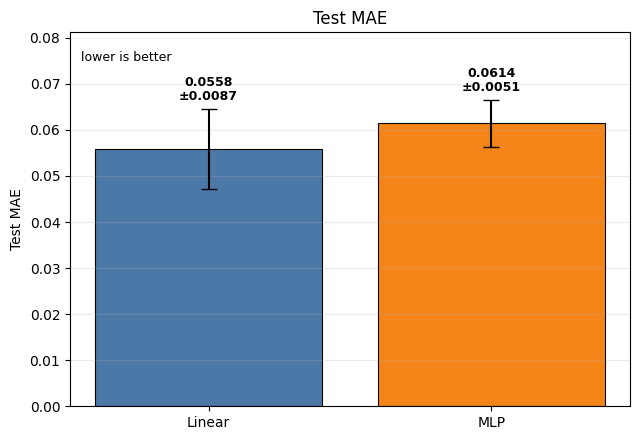

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/rmse_comparison_mean_std.png


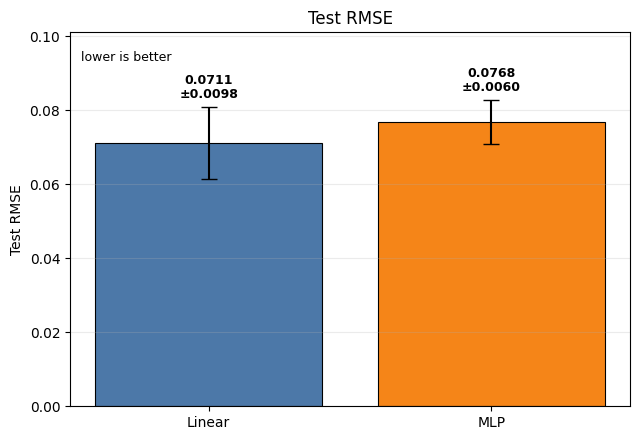

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/r2_comparison_mean_std.png


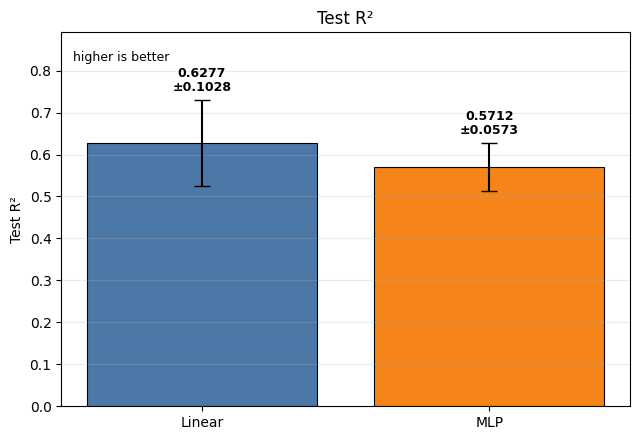

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/pearson_comparison_mean_std.png


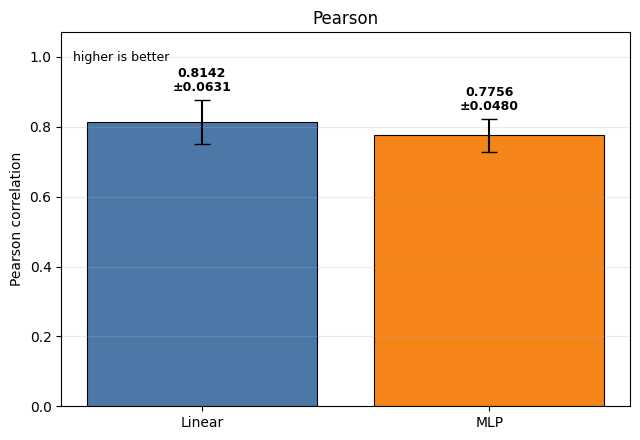

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/pred_std_ratio_comparison_mean_std.png


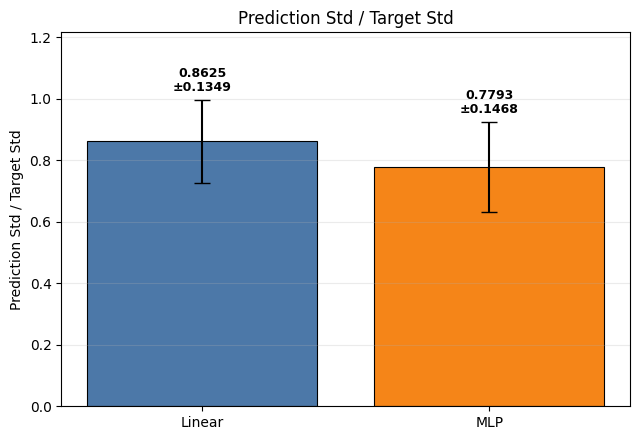

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/repeat_fraction_comparison_mean_std.png


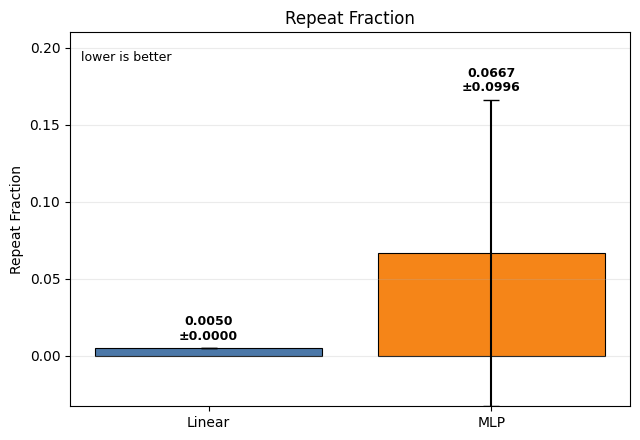

In [19]:
def plot_group_metric(metric: str, filename: str, ylabel: str | None = None, higher_is_better: bool | None = None) -> None:
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    plot_df = group_summary_numeric.copy()
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bars = ax.bar(
        plot_df["Head Type"],
        plot_df[mean_col],
        yerr=plot_df[std_col],
        capsize=6,
        color=["#4c78a8", "#f58518"],
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_title(metric)
    ax.set_ylabel(ylabel or metric)
    ax.grid(axis="y", alpha=0.25)

    means = plot_df[mean_col].astype(float).to_numpy()
    stds = plot_df[std_col].astype(float).fillna(0.0).to_numpy()
    y_min = min(0.0, float(np.nanmin(means - stds)))
    y_max = float(np.nanmax(means + stds))
    pad = (y_max - y_min) * 0.22 if y_max > y_min else max(abs(y_max) * 0.22, 0.05)
    ax.set_ylim(y_min, y_max + pad)

    for bar, mean_value, std_value in zip(bars, means, stds):
        label_y = mean_value + std_value + pad * 0.08
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f"{mean_value:.4f}\n±{std_value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            linespacing=1.15,
        )

    if higher_is_better is True:
        ax.text(0.02, 0.95, "higher is better", transform=ax.transAxes, va="top", fontsize=9)
    elif higher_is_better is False:
        ax.text(0.02, 0.95, "lower is better", transform=ax.transAxes, va="top", fontsize=9)
    fig.tight_layout()
    save_current_figure(OUT_DIR / filename)
    plt.show()

plot_group_metric("Test MAE", "mae_comparison_mean_std.png", ylabel="Test MAE", higher_is_better=False)
plot_group_metric("Test RMSE", "rmse_comparison_mean_std.png", ylabel="Test RMSE", higher_is_better=False)
plot_group_metric("Test R²", "r2_comparison_mean_std.png", ylabel="Test R²", higher_is_better=True)
plot_group_metric("Pearson", "pearson_comparison_mean_std.png", ylabel="Pearson correlation", higher_is_better=True)
plot_group_metric("Prediction Std / Target Std", "pred_std_ratio_comparison_mean_std.png", ylabel="Prediction Std / Target Std")
plot_group_metric("Repeat Fraction", "repeat_fraction_comparison_mean_std.png", ylabel="Repeat Fraction", higher_is_better=False)


,Head,Test MAE mean,Test MAE std,Test RMSE mean,Test RMSE std,Test R² mean,Test R² std,Pearson mean,Pearson std,Pred Std Ratio mean,Pred Std Ratio std,Repeat Fraction mean,Repeat Fraction std
0,Linear,0.0558,0.0087,0.0711,0.0098,0.6277,0.1028,0.8142,0.0631,0.8625,0.1349,0.0050,0.0000
1,MLP,0.0614,0.0051,0.0768,0.0060,0.5712,0.0573,0.7756,0.0480,0.7793,0.1468,0.0667,0.0996


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/head_ablation_main_result_summary.png


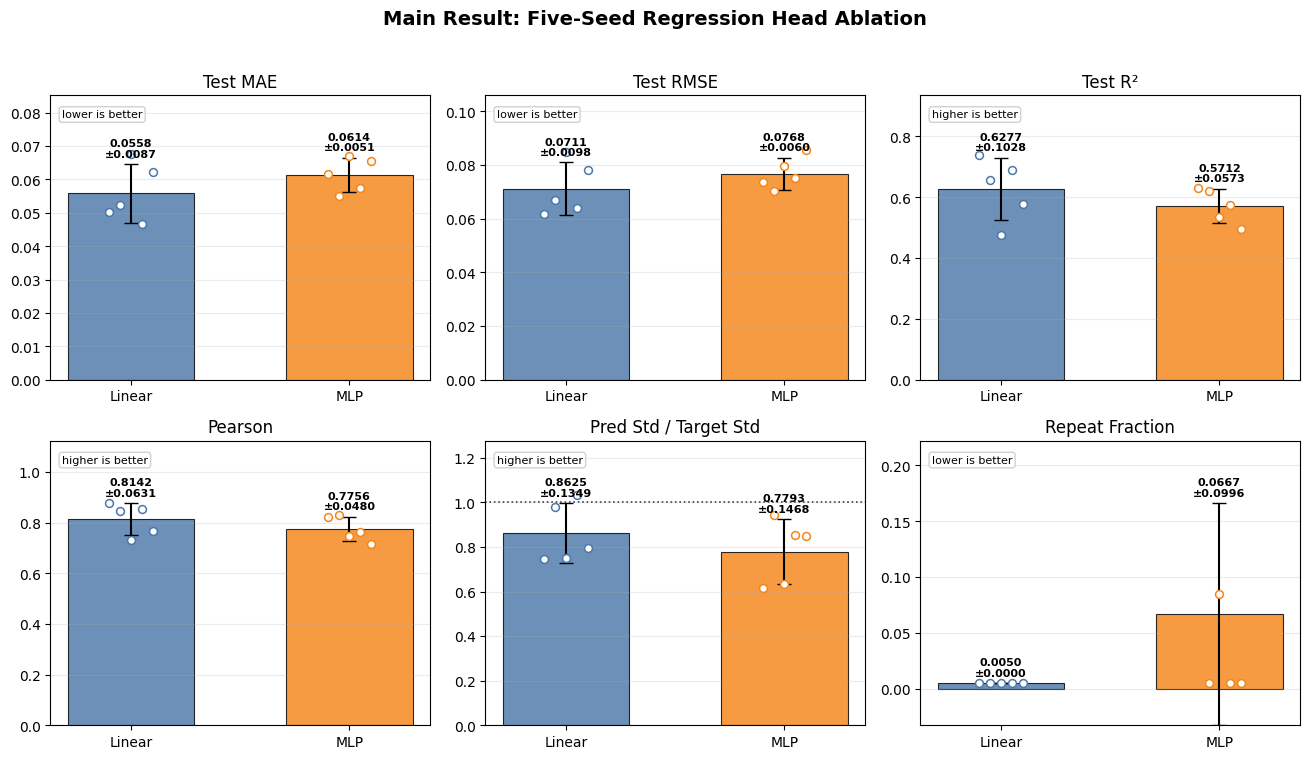

In [20]:
main_result_metrics = [
    ("Test MAE", "Test MAE", False),
    ("Test RMSE", "Test RMSE", False),
    ("Test R²", "Test R²", True),
    ("Pearson", "Pearson", True),
    ("Prediction Std / Target Std", "Pred Std / Target Std", True),
    ("Repeat Fraction", "Repeat Fraction", False),
]

summary_table_rows = []
for head_type in ["Linear", "MLP"]:
    row = {"Head": head_type}
    source_row = group_summary_numeric[group_summary_numeric["Head Type"] == head_type].iloc[0]
    row["Test MAE mean"] = source_row["Test MAE_mean"]
    row["Test MAE std"] = source_row["Test MAE_std"]
    row["Test RMSE mean"] = source_row["Test RMSE_mean"]
    row["Test RMSE std"] = source_row["Test RMSE_std"]
    row["Test R² mean"] = source_row["Test R²_mean"]
    row["Test R² std"] = source_row["Test R²_std"]
    row["Pearson mean"] = source_row["Pearson_mean"]
    row["Pearson std"] = source_row["Pearson_std"]
    row["Pred Std Ratio mean"] = source_row["Prediction Std / Target Std_mean"]
    row["Pred Std Ratio std"] = source_row["Prediction Std / Target Std_std"]
    row["Repeat Fraction mean"] = source_row["Repeat Fraction_mean"]
    row["Repeat Fraction std"] = source_row["Repeat Fraction_std"]
    summary_table_rows.append(row)

main_result_numeric_table = pd.DataFrame(summary_table_rows)
main_result_display_table = main_result_numeric_table.copy()
for column in main_result_display_table.columns:
    if column != "Head":
        main_result_display_table[column] = main_result_display_table[column].map(lambda value: f"{value:.4f}")

display(main_result_display_table)

fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.4))
axes = axes.ravel()
head_order = ["Linear", "MLP"]
colors = ["#4c78a8", "#f58518"]

for ax, (metric, title, higher_is_better) in zip(axes, main_result_metrics):
    means = []
    stds = []
    for head_type in head_order:
        source_row = group_summary_numeric[group_summary_numeric["Head Type"] == head_type].iloc[0]
        means.append(float(source_row[f"{metric}_mean"]))
        stds.append(float(source_row[f"{metric}_std"]))

    x = np.arange(len(head_order))
    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=5,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.82,
        width=0.58,
    )

    for idx, head_type in enumerate(head_order):
        seed_values = seed_results_df[seed_results_df["Head Type"] == head_type].sort_values("Seed")[metric].to_numpy(dtype=float)
        jitter = np.linspace(-0.10, 0.10, len(seed_values))
        ax.scatter(
            np.full(len(seed_values), x[idx]) + jitter,
            seed_values,
            s=32,
            color="white",
            edgecolor=colors[idx],
            linewidth=1.1,
            zorder=3,
        )

    y_min = min(0.0, float(np.nanmin(np.array(means) - np.array(stds))))
    y_max = float(np.nanmax(np.array(means) + np.array(stds)))
    pad = (y_max - y_min) * 0.28 if y_max > y_min else max(abs(y_max) * 0.28, 0.05)
    ax.set_ylim(y_min, y_max + pad)

    for bar, mean_value, std_value in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean_value + std_value + pad * 0.08,
            f"{mean_value:.4f}\n±{std_value:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            linespacing=1.1,
        )

    better_text = "higher is better" if higher_is_better else "lower is better"
    ax.text(
        0.03,
        0.95,
        better_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9),
    )
    if metric == "Prediction Std / Target Std":
        ax.axhline(1.0, color="#444444", linestyle=":", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(head_order)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Main Result: Five-Seed Regression Head Ablation", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save_current_figure(OUT_DIR / "head_ablation_main_result_summary.png")
plt.show()


The enhanced summary figure shows the main result of the controlled head ablation. The linear head improves MAE, RMSE, R², Pearson correlation, prediction spread, and repeat fraction relative to the original MLP head. Residual bias still remains, so the regression head explains an important failure mode but does not fully solve the remaining overprediction at low Omega_m and underprediction at high Omega_m.


## 9. Seed-Level MAE Comparison

This plot shows whether the head comparison is consistent seed by seed, rather than being driven by only one outlier seed.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed_level_mae_comparison.png


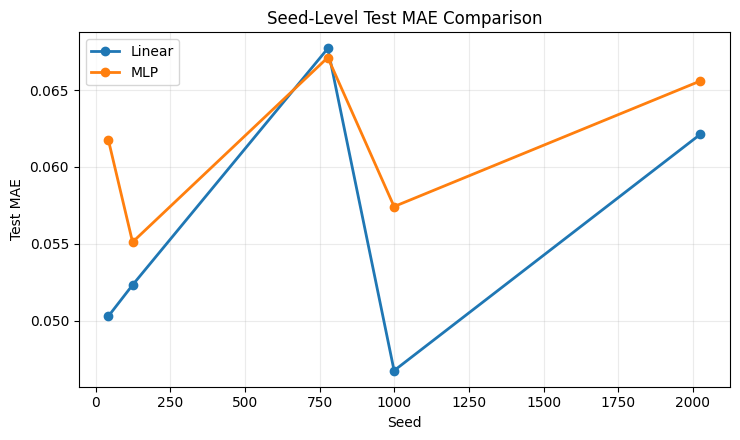

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for head_type, group in seed_results_df.sort_values("Seed").groupby("Head Type", sort=False):
    ax.plot(group["Seed"], group["Test MAE"], marker="o", linewidth=2, label=head_type)
ax.set_title("Seed-Level Test MAE Comparison")
ax.set_xlabel("Seed")
ax.set_ylabel("Test MAE")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_current_figure(OUT_DIR / "seed_level_mae_comparison.png")
plt.show()


## 10. Collapse Diagnostics

Prediction collapse is diagnosed using `Prediction Std / Target Std`. Values far below 1 indicate that predictions vary less than the true targets. Repeated identical predictions are diagnosed using rounded predictions at six decimal places.

Seed 42 is important because the MLP head previously showed repeated bias-output behavior: many test predictions were exactly equal, producing horizontal bands in true-vs-predicted plots and diagonal bands in residual plots. The linear head is checked for whether this repeated-output behavior disappears when the graph, data, split, and optimizer settings are unchanged.


In [22]:
collapse_table = seed_results_df[["Head Type", "Seed", "Prediction Std / Target Std", "Repeat Count", "Repeat Fraction", "Most Repeated Prediction"]].copy()
collapse_display = collapse_table.copy()
for col in ["Prediction Std / Target Std", "Repeat Fraction", "Most Repeated Prediction"]:
    collapse_display[col] = collapse_display[col].map(lambda x: f"{x:.6f}")

display(collapse_display)
save_csv(collapse_table, OUT_DIR / "collapse_diagnostics_seed_level.csv")
save_table_png(collapse_display, OUT_DIR / "collapse_diagnostics_seed_level_table.png", title="Prediction-Collapse and Repeated-Prediction Diagnostics")


,Head Type,Seed,Prediction Std / Target Std,Repeat Count,Repeat Fraction,Most Repeated Prediction
0,Linear,42,0.748353,1,0.004975,0.078997
1,Linear,123,0.979391,1,0.004975,0.057471
2,Linear,777,0.752037,1,0.004975,0.030117
3,Linear,999,1.034781,1,0.004975,-0.021409
4,Linear,2025,0.797722,1,0.004975,0.029120
5,MLP,42,0.613933,47,0.233831,0.227156
6,MLP,123,0.945590,1,0.004975,0.095541
7,MLP,777,0.634904,17,0.084577,0.209070
8,MLP,999,0.853122,1,0.004975,0.124151
9,MLP,2025,0.848903,1,0.004975,0.073541


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/collapse_diagnostics_seed_level.csv
Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/collapse_diagnostics_seed_level_table.png


## 11. Prediction Diagnostic Plots

The next plots combine all seeds per head. True-vs-predicted scatter plots include the 1:1 line. Residual plots include the zero-residual line. Histograms compare prediction distributions between the two heads.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/true_vs_predicted_mlp_all_seeds.png


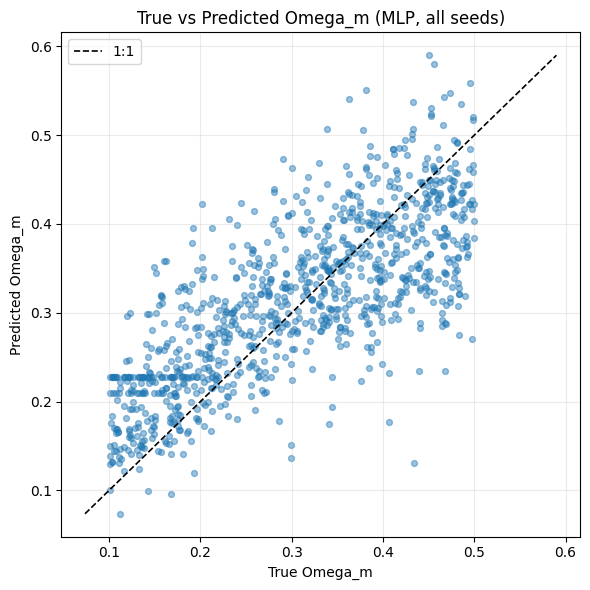

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/true_vs_predicted_linear_all_seeds.png


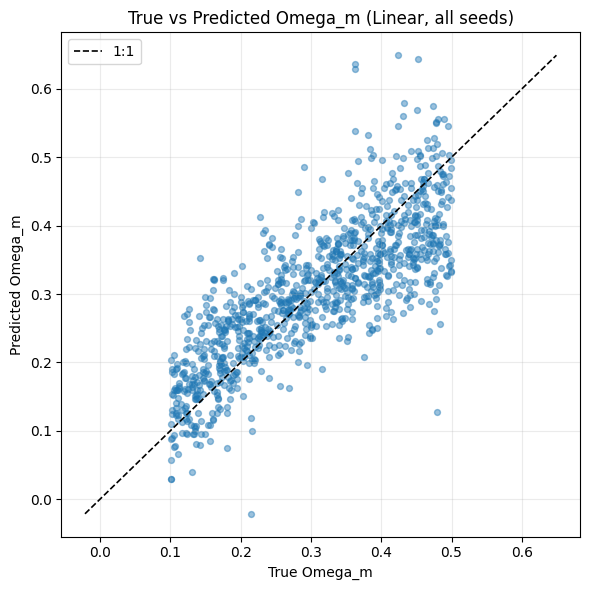

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/residuals_vs_true_mlp_all_seeds.png


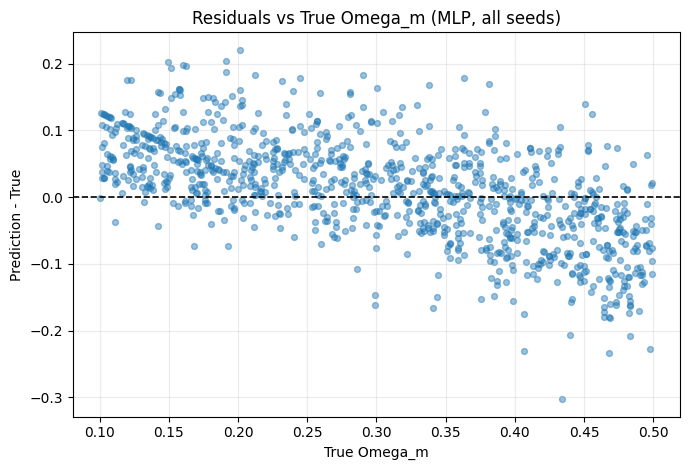

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/residuals_vs_true_linear_all_seeds.png


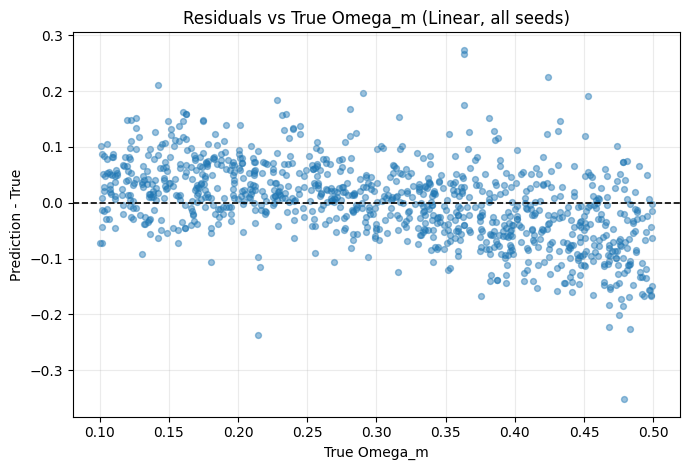

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/prediction_distribution_mlp_vs_linear.png


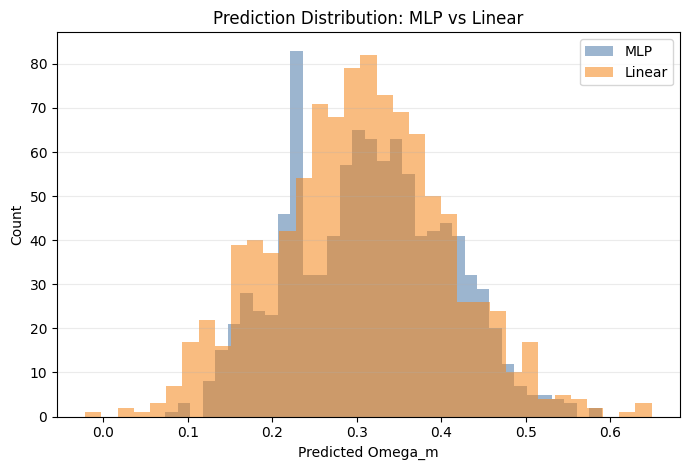

In [23]:
def combined_predictions(head_type: str) -> pd.DataFrame:
    frames = [df for df in predictions_by_experiment.values() if df["Head Type"].iloc[0] == head_type]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def plot_true_vs_pred(head_type: str, filename: str) -> None:
    df = combined_predictions(head_type)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df["true"], df["pred"], alpha=0.45, s=18)
    lo = float(min(df["true"].min(), df["pred"].min()))
    hi = float(max(df["true"].max(), df["pred"].max()))
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1.2, label="1:1")
    ax.set_title(f"True vs Predicted Omega_m ({head_type}, all seeds)")
    ax.set_xlabel("True Omega_m")
    ax.set_ylabel("Predicted Omega_m")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    save_current_figure(OUT_DIR / filename)
    plt.show()


def plot_residuals(head_type: str, filename: str) -> None:
    df = combined_predictions(head_type)
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.scatter(df["true"], df["residual"], alpha=0.45, s=18)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(f"Residuals vs True Omega_m ({head_type}, all seeds)")
    ax.set_xlabel("True Omega_m")
    ax.set_ylabel("Prediction - True")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_current_figure(OUT_DIR / filename)
    plt.show()

plot_true_vs_pred("MLP", "true_vs_predicted_mlp_all_seeds.png")
plot_true_vs_pred("Linear", "true_vs_predicted_linear_all_seeds.png")
plot_residuals("MLP", "residuals_vs_true_mlp_all_seeds.png")
plot_residuals("Linear", "residuals_vs_true_linear_all_seeds.png")

mlp_df = combined_predictions("MLP")
linear_df = combined_predictions("Linear")
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.hist(mlp_df["pred"], bins=35, alpha=0.55, label="MLP", color="#4c78a8")
ax.hist(linear_df["pred"], bins=35, alpha=0.55, label="Linear", color="#f58518")
ax.set_title("Prediction Distribution: MLP vs Linear")
ax.set_xlabel("Predicted Omega_m")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
save_current_figure(OUT_DIR / "prediction_distribution_mlp_vs_linear.png")
plt.show()


## 12. Best-Seed Sorted Curve

This section selects the best MLP seed and the best Linear seed by lowest test MAE. The sorted curves compare the target trend against predictions for the best run in each group.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/sorted_true_vs_predicted_best_mlp_vs_best_linear.png


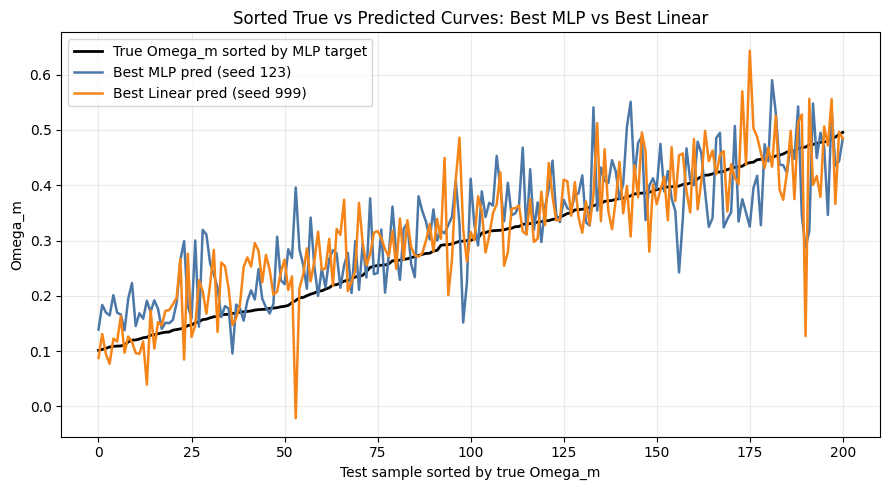

Best MLP seed: 123, Test MAE=0.055114
Best Linear seed: 999, Test MAE=0.046755


In [24]:
best_mlp_row = seed_results_df[seed_results_df["Head Type"] == "MLP"].sort_values("Test MAE").iloc[0]
best_linear_row = seed_results_df[seed_results_df["Head Type"] == "Linear"].sort_values("Test MAE").iloc[0]

best_mlp_df = predictions_by_experiment[best_mlp_row["Experiment"]].sort_values("true").reset_index(drop=True)
best_linear_df = predictions_by_experiment[best_linear_row["Experiment"]].sort_values("true").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(best_mlp_df.index, best_mlp_df["true"], color="black", linewidth=2.0, label="True Omega_m sorted by MLP target")
ax.plot(best_mlp_df.index, best_mlp_df["pred"], color="#4c78a8", linewidth=1.8, label=f"Best MLP pred (seed {int(best_mlp_row['Seed'])})")
ax.plot(best_linear_df.index, best_linear_df["pred"], color="#f58518", linewidth=1.8, label=f"Best Linear pred (seed {int(best_linear_row['Seed'])})")
ax.set_title("Sorted True vs Predicted Curves: Best MLP vs Best Linear")
ax.set_xlabel("Test sample sorted by true Omega_m")
ax.set_ylabel("Omega_m")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_current_figure(OUT_DIR / "sorted_true_vs_predicted_best_mlp_vs_best_linear.png")
plt.show()

print(f"Best MLP seed: {int(best_mlp_row['Seed'])}, Test MAE={best_mlp_row['Test MAE']:.6f}")
print(f"Best Linear seed: {int(best_linear_row['Seed'])}, Test MAE={best_linear_row['Test MAE']:.6f}")


## 13. Seed-42 Special Diagnostic

Seed 42 is important because the MLP seed42 run produced many identical predictions equal to the final regression bias. This created horizontal bands in true-vs-predicted space and diagonal bands in residual plots. Because the linear-head seed42 run keeps the graph, data, split, and optimizer settings fixed, it tests whether this repeated-output behavior is caused by the nonlinear regression head rather than by graph construction alone.


In [25]:
seed42_table = seed_results_df[seed_results_df["Seed"] == 42][["Head Type", "Seed", "Test MAE", "Test RMSE", "Test R²", "Prediction Std / Target Std", "Most Repeated Prediction", "Repeat Count", "Repeat Fraction"]].copy()
save_csv(seed42_table, OUT_DIR / "seed42_repeated_prediction_diagnostic.csv")

seed42_display = seed42_table.copy()
for col in ["Test MAE", "Test RMSE", "Test R²", "Prediction Std / Target Std", "Most Repeated Prediction", "Repeat Fraction"]:
    seed42_display[col] = seed42_display[col].map(lambda x: f"{x:.6f}")

display(seed42_display)
save_table_png(seed42_display, OUT_DIR / "seed42_repeated_prediction_diagnostic_table.png", title="Seed-42 Repeated-Prediction Diagnostic")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed42_repeated_prediction_diagnostic.csv


,Head Type,Seed,Test MAE,Test RMSE,Test R²,Prediction Std / Target Std,Most Repeated Prediction,Repeat Count,Repeat Fraction
0,Linear,42,0.050295,0.061928,0.738381,0.748353,0.078997,1,0.004975
5,MLP,42,0.061761,0.073652,0.629939,0.613933,0.227156,47,0.233831


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed42_repeated_prediction_diagnostic_table.png


## 14. Interpretation Checklist

The checklist below converts the computed tables into explicit thesis-facing answers. These statements are generated from the seed-level results rather than manually hardcoded.


In [26]:
summary_lookup = group_summary_numeric.set_index("Head Type")
mlp = summary_lookup.loc["MLP"]
linear = summary_lookup.loc["Linear"]

def yes_no(condition: bool) -> str:
    return "Yes" if bool(condition) else "No"

checklist = pd.DataFrame([
    {"Question": "Did Linear reduce mean Test MAE?", "Result": yes_no(linear["Test MAE_mean"] < mlp["Test MAE_mean"]), "MLP": f"{mlp['Test MAE_mean']:.6f}", "Linear": f"{linear['Test MAE_mean']:.6f}"},
    {"Question": "Did Linear reduce mean RMSE?", "Result": yes_no(linear["Test RMSE_mean"] < mlp["Test RMSE_mean"]), "MLP": f"{mlp['Test RMSE_mean']:.6f}", "Linear": f"{linear['Test RMSE_mean']:.6f}"},
    {"Question": "Did Linear improve mean R²?", "Result": yes_no(linear["Test R²_mean"] > mlp["Test R²_mean"]), "MLP": f"{mlp['Test R²_mean']:.6f}", "Linear": f"{linear['Test R²_mean']:.6f}"},
    {"Question": "Did Linear reduce repeated predictions?", "Result": yes_no(linear["Repeat Fraction_mean"] < mlp["Repeat Fraction_mean"]), "MLP": f"{mlp['Repeat Fraction_mean']:.6f}", "Linear": f"{linear['Repeat Fraction_mean']:.6f}"},
    {"Question": "Did Linear improve prediction spread?", "Result": yes_no(abs(1.0 - linear["Prediction Std / Target Std_mean"]) < abs(1.0 - mlp["Prediction Std / Target Std_mean"])), "MLP": f"{mlp['Prediction Std / Target Std_mean']:.6f}", "Linear": f"{linear['Prediction Std / Target Std_mean']:.6f}"},
    {"Question": "Does this indicate graph construction is wrong?", "Result": "No direct evidence", "MLP": "same graph/data/splits", "Linear": "only head changed"},
    {"Question": "Does this support the regression-head bottleneck hypothesis?", "Result": yes_no((linear["Test MAE_mean"] < mlp["Test MAE_mean"]) and (linear["Repeat Fraction_mean"] < mlp["Repeat Fraction_mean"])), "MLP": "nonlinear head", "Linear": "linear head"},
])

save_csv(checklist, OUT_DIR / "interpretation_checklist.csv")
display(checklist)
save_table_png(checklist, OUT_DIR / "interpretation_checklist_table.png", title="Interpretation Checklist")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/interpretation_checklist.csv


,Question,Result,MLP,Linear
0,Did Linear reduce mean Test MAE?,Yes,0.061404,0.055843
1,Did Linear reduce mean RMSE?,Yes,0.076820,0.071136
2,Did Linear improve mean R²?,Yes,0.571180,0.627697
3,Did Linear reduce repeated predictions?,Yes,0.066667,0.004975
4,Did Linear improve prediction spread?,Yes,0.779290,0.862457
5,Does this indicate graph construction is wrong?,No direct evidence,same graph/data/splits,only head changed
6,Does this support the regression-head bottlene...,Yes,nonlinear head,linear head


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/interpretation_checklist_table.png


## 15. Thesis-Style Conclusion

This controlled ablation compares the original nonlinear MLP regression head against a linear regression head while keeping the dataset, graph construction, split ratios, seeds, pooling, hidden dimension, number of layers, optimizer settings, and training schedule fixed.

The result should be interpreted as a targeted test of the regression head. If the linear head improves mean MAE/RMSE/R² and reduces repeated identical predictions, then the evidence supports the hypothesis that the original nonlinear MLP regression head can act as a bottleneck for `Omega_m` prediction. In particular, reducing the repeated-bias behavior without changing graph construction argues against graph construction being the direct cause of that specific failure mode.

This does not prove that the graph construction is perfect. It only shows that, under unchanged graph/data/split conditions, changing the regression head changes the repeated-prediction behavior. Therefore, the repeated-bias-output failure is more directly associated with the head and its interaction with learned embeddings than with the graph dataset alone.


## Main Result: Five-Seed Regression Head Ablation

Across five matched random seeds, replacing the original nonlinear MLP regression head with a linear head improved the average EvolveGCN-H performance on the 750U Top1000 dataset.

| Head | Test MAE | Test RMSE | Test R² | Pearson | Pred Std / Target Std | Repeat Fraction |
|---|---:|---:|---:|---:|---:|---:|
| Linear | **0.0558 ± 0.0087** | **0.0711 ± 0.0098** | **0.6277 ± 0.1028** | **0.8142 ± 0.0631** | **0.8625 ± 0.1349** | **0.005 ± 0.000** |
| MLP | 0.0614 ± 0.0051 | 0.0768 ± 0.0060 | 0.5712 ± 0.0573 | 0.7756 ± 0.0480 | 0.7793 ± 0.1468 | 0.066 ± 0.099 |

The linear head reduced MAE and RMSE, improved R² and Pearson correlation, increased prediction spread, and almost eliminated repeated identical predictions. This supports the hypothesis that the original MLP regression head was a bottleneck. However, residual plots still show systematic overprediction at low Omega_m and underprediction at high Omega_m, so the regression head is not the only remaining limitation.

This result argues against graph construction being the direct cause of the repeated-prediction pathology, because the graph dataset, split, model encoder, pooling, optimizer settings, and seed set were unchanged; only the regression head changed.


## 16. Output Artifacts

The final cell lists all CSV and PNG files written by this notebook.


In [27]:
print("CSV files created:")
for path in SAVED_CSVS:
    print(f"- {path}")

print("\nPNG files created:")
for path in SAVED_PNGS:
    print(f"- {path}")

if warning_df.empty:
    print("\nWarnings: none")
else:
    print("\nWarnings:")
    display(warning_df)


CSV files created:
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed_level_results.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/group_summary_numeric.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/group_summary_mean_std.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/collapse_diagnostics_seed_level.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed42_repeated_prediction_diagnostic.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/interpretation_checklist.csv

PNG files created:
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/seed_level_results_table.png
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/group_summary_mean_std_table.png
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/mae_comparison_mean_std.png
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_head_ablation_results/rmse_comparison_me